![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [38]:
import warnings
warnings.filterwarnings('ignore')

In [39]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [40]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [41]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [42]:
# Celda 1
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def square_error(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2)

# Desarrollado en el lab semana 1
class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y), depth=0)

    def _build_tree(self, X, y, depth):
        if len(set(y)) == 1 or depth == self.max_depth:
            return np.mean(y)
        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.mean(y)
        left  = X[:, feature] <= threshold
        right = ~left
        return (feature, threshold,
                self._build_tree(X[left], y[left], depth + 1),
                self._build_tree(X[right], y[right], depth + 1))

    def _best_split(self, X, y):
        best_mse, best_feature, best_threshold = float('inf'), None, None
        for feature in range(X.shape[1]):
            for threshold in np.percentile(X[:, feature], range(0, 101, 5)):
                left = X[:, feature] <= threshold
                right = ~left
                if left.sum() == 0 or right.sum() == 0:
                    continue
                mse = (len(y[left])  * square_error(y[left], y[left].mean()) +
                       len(y[right]) * square_error(y[right], y[right].mean())) / len(y)
                if mse < best_mse:
                    best_mse, best_feature, best_threshold = mse, feature, threshold
        return best_feature, best_threshold

    def predict(self, X):
        return np.array([self._predict_single(x, self.tree) for x in np.array(X)])

    def _predict_single(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        feature, threshold, left, right = tree
        return self._predict_single(x, left if x[feature] <= threshold else right)
    
    
dts = DecisionTreeRegressorScratch(max_depth=50)
dts.fit(X_train, y_train)
y_pred = dts.predict(X_test)

dts_mse_test = mean_squared_error(y_test, y_pred)
dts_mae_test = mean_absolute_error(y_test, y_pred)
dts_r2_test = r2_score(y_test, y_pred)
dts_mse_train = mean_squared_error(y_train, dts.predict(X_train))
dts_mae_train = mean_absolute_error(y_train, dts.predict(X_train))

print("---------------------")
print("Metricas arbol manual")
print("---------------------")
print(f"MSE Train: {dts_mse_train:.2f}")
print(f"MAE Train: {dts_mae_train:.2f}")
print(f"MSE Test: {dts_mse_test:.2f}")
print(f"MAE Test: {dts_mae_test:.2f}")
print(f"R2 Test: {dts_r2_test:.2f}")

---------------------
Metricas arbol manual
---------------------
MSE Train: 6385.18
MAE Train: 5.95
MSE Test: 4741969.77
MAE Test: 1631.73
R2 Test: 0.69


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [43]:
# Celda 2

class BaggingRegressorScratch:
    def __init__(self, base_estimator_class, n_estimators=10):
        self.n_estimators = n_estimators
        self.base_estimator_class = base_estimator_class
        self.estimators = []

    def fit(self, X, y):
        for i in range(self.n_estimators):
            indices = np.random.choice(X.index, len(X), replace=True)
            estimator = self.base_estimator_class(max_depth=50)
            estimator.fit(X.loc[indices], y.loc[indices])
            self.estimators.append(estimator)

    def predict(self, X):
        predictions = np.array([estimator.predict(X) for estimator in self.estimators])
        return np.mean(predictions, axis=0)
    
brs = BaggingRegressorScratch(base_estimator_class=DecisionTreeRegressorScratch, n_estimators=10)

brs.fit(X_train, y_train)
y_pred_brs = brs.predict(X_test)

brs_mse_test = mean_squared_error(y_test, y_pred_brs)
brs_mae_test = mean_absolute_error(y_test, y_pred_brs)
brs_r2_test = r2_score(y_test, y_pred_brs)
brs_mse_train = mean_squared_error(y_train, brs.predict(X_train))
brs_mae_train = mean_absolute_error(y_train, brs.predict(X_train))

print("-----------------------")
print("Metricas bagging manual")
print("-----------------------")

print(f"MSE Train: {brs_mse_train:.2f}")
print(f"MAE Train: {brs_mae_train:.2f}")
print(f"MSE Test: {brs_mse_test:.2f}")
print(f"MAE Test: {brs_mae_test:.2f}")
print(f"R2 Test: {brs_r2_test:.2f}")

-----------------------
Metricas bagging manual
-----------------------
MSE Train: 534466.47
MAE Train: 506.94
MSE Test: 3229714.64
MAE Test: 1341.12
R2 Test: 0.79


### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [44]:
# Celda 3
from math import log
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()
n_features = X_train.shape[1]

br = BaggingRegressor(estimator=dtr, n_estimators=10, max_features=int(log(n_features)), random_state=1)

br.fit(X_train, y_train)
y_pred_br = br.predict(X_test)

br_mse_test = mean_squared_error(y_test, y_pred_br)
br_mae_test = mean_absolute_error(y_test, y_pred_br)
br_r2_test = r2_score(y_test, y_pred_br)
br_mse_train = mean_squared_error(y_train, br.predict(X_train))
br_mae_train = mean_absolute_error(y_train, br.predict(X_train))


print("-----------------------")
print("Metricas bagging sklearn")
print("-----------------------")
print(f"MSE Train: {br_mse_train:.2f}")
print(f"MAE Train: {br_mae_train:.2f}")
print(f"MSE Test: {br_mse_test:.2f}")
print(f"MAE Test: {br_mae_test:.2f}")
print(f"R2 Test: {br_r2_test:.2f}")

-----------------------
Metricas bagging sklearn
-----------------------
MSE Train: 6005416.43
MAE Train: 1910.64
MSE Test: 7134309.37
MAE Test: 2074.98
R2 Test: 0.53


### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [45]:
# Celda 4

from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=10, random_state=1)

rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)

rfr_mse_test = mean_squared_error(y_test, y_pred_rfr)
rfr_mae_test = mean_absolute_error(y_test, y_pred_rfr)
rfr_r2_test = r2_score(y_test, y_pred_rfr)
rfr_mse_train = mean_squared_error(y_train, rfr.predict(X_train))
rfr_mae_train = mean_absolute_error(y_train, rfr.predict(X_train))

print("-------------------------")
print("Metricas random forest sklearn")
print("-------------------------")
print(f"MSE Train: {rfr_mse_train:.2f}")
print(f"MAE Train: {rfr_mae_train:.2f}")
print(f"MSE Test: {rfr_mse_test:.2f}")
print(f"MAE Test: {rfr_mae_test:.2f}")
print(f"R2 Test: {rfr_r2_test:.2f}")


-------------------------
Metricas random forest sklearn
-------------------------
MSE Train: 541251.33
MAE Train: 512.24
MSE Test: 3190693.05
MAE Test: 1332.12
R2 Test: 0.79


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [46]:
# Celda 5
from sklearn.model_selection import cross_val_score
from matplotlib import pyplot as plt

max_depths = np.arange(1, 50, 5)
max_features = np.arange(1, X_train.shape[1] + 1, 2)
n_estimators = np.arange(1, 250, 25)

depth_mse = []
feature_mse = []
estimator_mse = []

for depth in max_depths:
    rfr = RandomForestRegressor(max_depth=depth, random_state=1)
    depth_mse.append(cross_val_score(rfr, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean())

for features in max_features:
    rfr = RandomForestRegressor(max_features=features, random_state=1)
    feature_mse.append(cross_val_score(rfr, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean())
    
for n in n_estimators:
    rfr = RandomForestRegressor(n_estimators=n, random_state=1)
    estimator_mse.append(cross_val_score(rfr, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean())


Text(0.5, 1.0, 'MSE vs n_estimators')

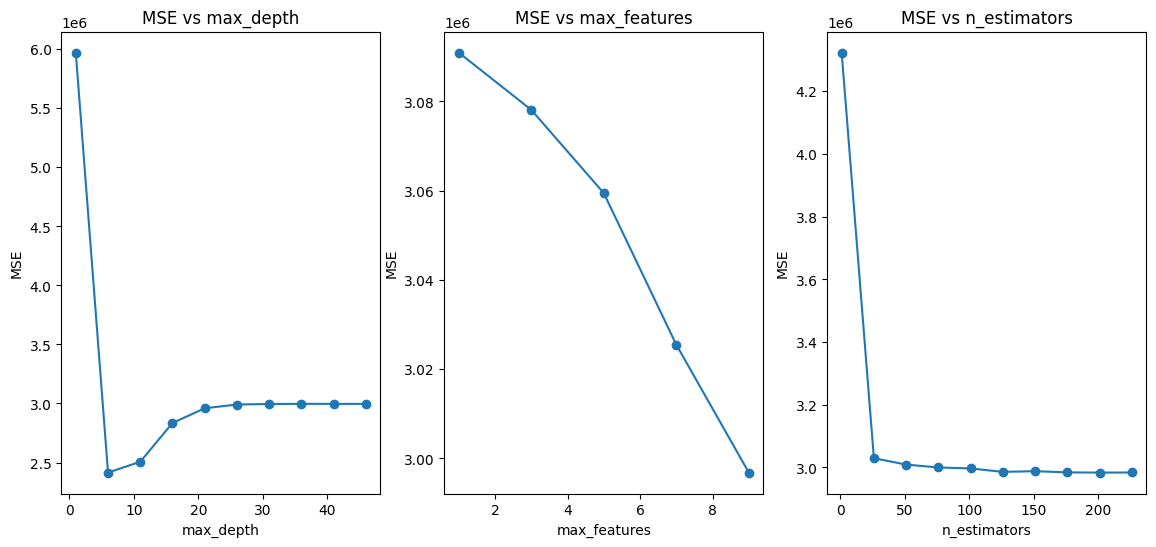

In [47]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))

axs[0].plot(max_depths, -np.array(depth_mse), marker='o')
axs[0].set_xlabel('max_depth')
axs[0].set_ylabel('MSE')
axs[0].set_title('MSE vs max_depth')

axs[1].plot(max_features, -np.array(feature_mse), marker='o')
axs[1].set_xlabel('max_features')
axs[1].set_ylabel('MSE')
axs[1].set_title('MSE vs max_features')

axs[2].plot(n_estimators, -np.array(estimator_mse), marker='o')
axs[2].set_xlabel('n_estimators')
axs[2].set_ylabel('MSE')
axs[2].set_title('MSE vs n_estimators')

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': max_depths,
    'max_features': max_features,
    'n_estimators': n_estimators
}

rfr_grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=1), param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rfr_grid_search.fit(X_train, y_train)
rfr_y_pred_grid = rfr_grid_search.predict(X_test)

rfr_grid_mse_test = mean_squared_error(y_test, rfr_y_pred_grid)
rfr_grid_mae_test = mean_absolute_error(y_test, rfr_y_pred_grid)
rfr_grid_r2_test = r2_score(y_test, rfr_y_pred_grid)

print("Mejores parámetros:", rfr_grid_search.best_params_)

print("-------------------------")
print("Metricas random forest optimizado sklearn")
print("-------------------------")
print(f"MSE Test: {rfr_grid_mse_test:.2f}")
print(f"MAE Test: {rfr_grid_mae_test:.2f}")
print(f"R2 Test: {rfr_grid_r2_test:.2f}")

Mejores parámetros: {'max_depth': np.int64(6), 'max_features': np.int64(7), 'n_estimators': np.int64(126)}
-------------------------
Metricas random forest optimizado sklearn
-------------------------
MSE Test: 2473874.35
MAE Test: 1158.43
R2 Test: 0.84


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [49]:
# Celda 6
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=1)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_mse_test = mean_squared_error(y_test, y_pred_xgb)
xgb_mae_test = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2_test = r2_score(y_test, y_pred_xgb)
xgb_mse_train = mean_squared_error(y_train, xgb.predict(X_train))
xgb_mae_train = mean_absolute_error(y_train, xgb.predict(X_train))

print("-------------------------")
print("Metricas XGBoost")
print("-------------------------")
print(f"MSE Train: {xgb_mse_train:.2f}")
print(f"MAE Train: {xgb_mae_train:.2f}")
print(f"MSE Test: {xgb_mse_test:.2f}")
print(f"MAE Test: {xgb_mae_test:.2f}")
print(f"R2 Test: {xgb_r2_test:.2f}")

-------------------------
Metricas XGBoost
-------------------------
MSE Train: 1537409.75
MAE Train: 909.87
MSE Test: 2576781.00
MAE Test: 1185.23
R2 Test: 0.83


### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

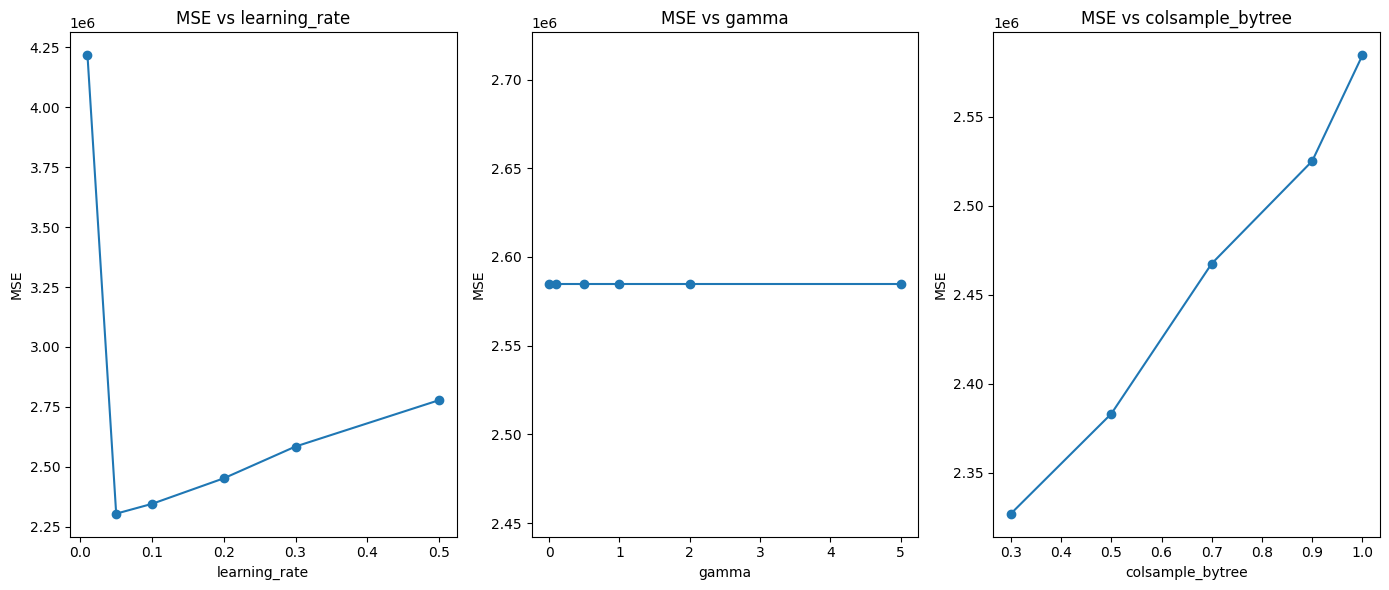

Mejores parámetros: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.05}
-------------------------
Metricas XGBoost calibrado
-------------------------
MSE Test: 2405371.25
MAE Test: 1136.25
R2 Test:  0.8427


In [ ]:
# Celda 7
learning_rates=[0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
gammas = [0, 0.1, 0.5, 1, 2, 5]
colsample_bytrees=[0.3, 0.5, 0.7, 0.9, 1.0]

lr_mse = []
gamma_mse= []
col_mse = []

for lr in learning_rates:
    xgb_cv = XGBRegressor(learning_rate=lr, random_state=1)
    lr_mse.append(cross_val_score(xgb_cv, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean())

for g in gammas:
    xgb_cv = XGBRegressor(gamma=g, random_state=1)
    gamma_mse.append(cross_val_score(xgb_cv, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean())

for col in colsample_bytrees:
    xgb_cv = XGBRegressor(colsample_bytree=col, random_state=1)
    col_mse.append(cross_val_score(xgb_cv, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean())

fig, axs = plt.subplots(1, 3, figsize=(14, 6))

axs[0].plot(learning_rates, -np.array(lr_mse), marker='o')
axs[0].set_xlabel('learning_rate')
axs[0].set_ylabel('MSE')
axs[0].set_title('MSE vs learning_rate')

axs[1].plot(gammas, -np.array(gamma_mse), marker='o')
axs[1].set_xlabel('gamma')
axs[1].set_ylabel('MSE')
axs[1].set_title('MSE vs gamma')

axs[2].plot(colsample_bytrees, -np.array(col_mse), marker='o')
axs[2].set_xlabel('colsample_bytree')
axs[2].set_ylabel('MSE')
axs[2].set_title('MSE vs colsample_bytree')

plt.tight_layout()
plt.show()

param_grid_xgb = {'learning_rate': learning_rates,'gamma': gammas,'colsample_bytree': colsample_bytrees}

xgb_grid = GridSearchCV(XGBRegressor(random_state=1), param_grid_xgb, cv=3,scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
y_pred_xgb_tuned = xgb_grid.predict(X_test)

print("Mejores parámetros:", xgb_grid.best_params_)
print("-------------------------")
print("Metricas XGBoost calibrado")
print("-------------------------")
print(f"MSE Test: {mean_squared_error(y_test, y_pred_xgb_tuned):.2f}")
print(f"MAE Test: {mean_absolute_error(y_test, y_pred_xgb_tuned):.2f}")
print(f"R2 Test: {r2_score(y_test, y_pred_xgb_tuned):.4f}")


### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [51]:
# Celda 8
